In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# [1] Cấu hình thư mục gốc
DATA_DIR = "../../data/raw"

# Nhóm Bảng chính (Main Tables)
MAIN_TRAIN_FILE = os.path.join(DATA_DIR, "application_train.csv")
MAIN_TEST_FILE  = os.path.join(DATA_DIR, "application_test.csv")

# Nhóm Luồng lịch sử BÊN NGOÀI Home Credit (Credit Bureau Stream)
BUREAU_FILE      = os.path.join(DATA_DIR, "bureau.csv")
BUREAU_BAL_FILE  = os.path.join(DATA_DIR, "bureau_balance.csv")

# Nhóm Luồng lịch sử BÊN TRONG Home Credit (Internal Behavioral Stream)
PREV_APP_FILE    = os.path.join(DATA_DIR, "previous_application.csv")
INS_PAYMENT_FILE = os.path.join(DATA_DIR, "installments_payments.csv")
POS_CASH_FILE    = os.path.join(DATA_DIR, "POS_CASH_balance.csv")
CREDIT_CARD_FILE = os.path.join(DATA_DIR, "credit_card_balance.csv")

# File phụ bổ sung thông tin mô tả
COL_DESC_FILE    = os.path.join(DATA_DIR, "HomeCredit_columns_description.csv")

Đang đọc file application_train.csv...

TOP 20 TƯƠNG QUAN DƯƠNG MẠNH NHẤT VỚI TARGET (Rủi ro tăng)
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
FLAG_WORK_PHONE                0.028524
AMT_REQ_CREDIT_BUREAU_YEAR     0.019930
CNT_CHILDREN                   0.019187
CNT_FAM_MEMBERS                0.009308
OBS_30_CNT_SOCIAL_CIRCLE       0.009131
OBS_60_CNT_SOCIAL_CIRCLE       0.009022

TOP 20 TƯƠNG QUAN ÂM MẠNH NHẤT VỚI TARGET (An toàn tăng)
EXT_SOURCE_3                 -0.178919
EXT_

/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3071823974.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3071823974.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


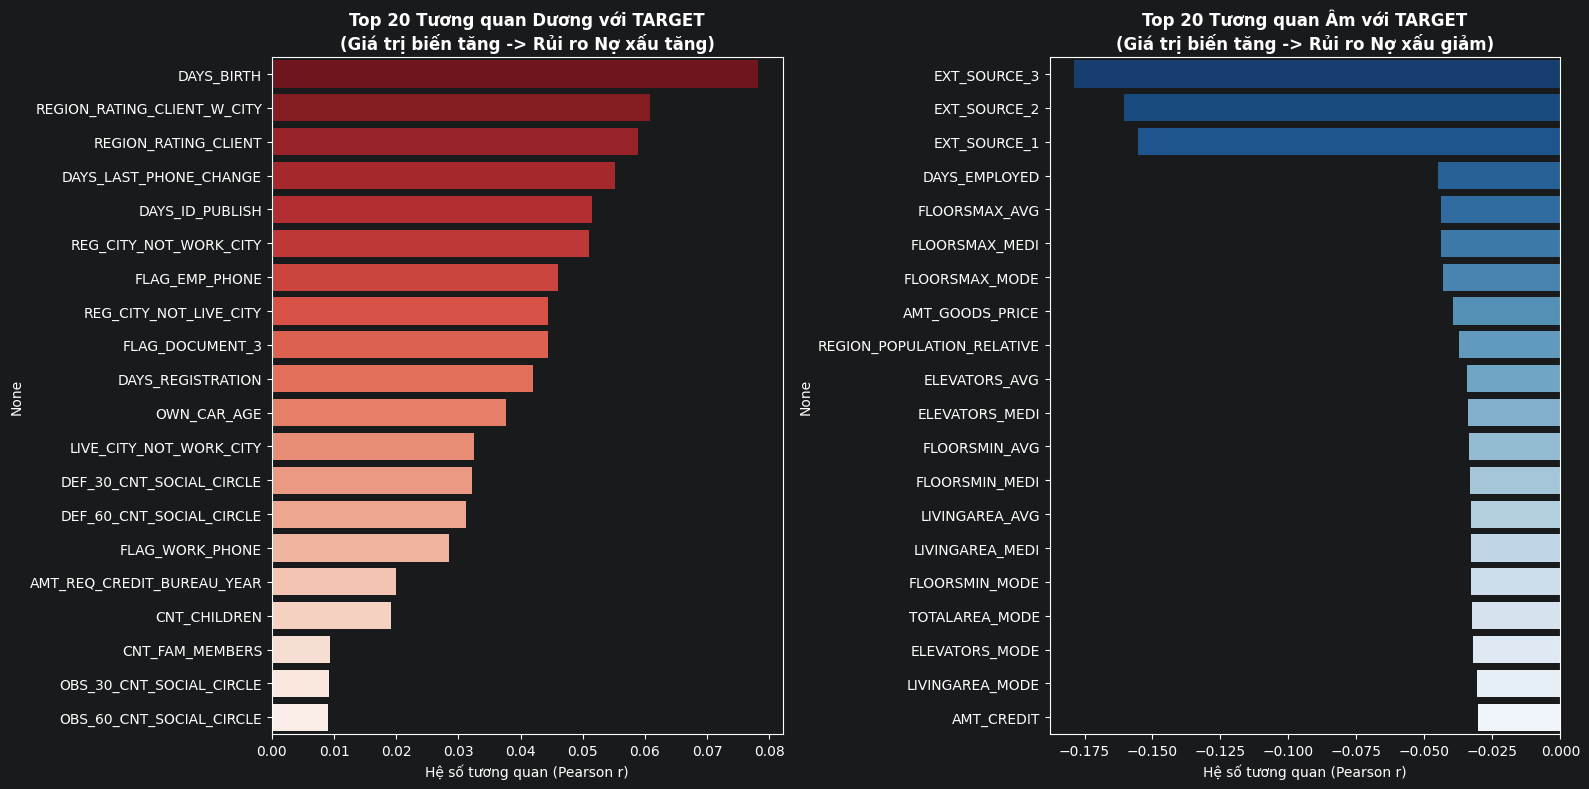

In [10]:
# [2] Đọc dữ liệu bảng chính application_train
print("Đang đọc file application_train.csv...")
df_train = pd.read_csv(MAIN_TRAIN_FILE)

# [3] Tính toán hệ số tương quan với biến TARGET
# Lưu ý: Chỉ tính trên các cột dạng số (numeric)
numeric_df = df_train.select_dtypes(include=["number"])
correlations = numeric_df.corr()["TARGET"].drop("TARGET")  # Bỏ dòng tương quan của TARGET với chính nó

# [4] Lấy Top 20 Tương quan Dương cao nhất (Positive Correlation)
# Ý nghĩa: Biến này CÀNG TĂNG -> Tỷ lệ nợ xấu (TARGET = 1) CÀNG TĂNG
top20_positive = correlations.sort_values(ascending=False).head(20)

# [5] Lấy Top 20 Tương quan Âm cao nhất (Negative Correlation)
# Ý nghĩa: Biến này CÀNG TĂNG -> Tỷ lệ nợ xấu (TARGET = 1) CÀNG GIẢM
top20_negative = correlations.sort_values(ascending=True).head(20)

# In kết quả ra màn hình dạng bảng
print("\n" + "=" * 50)
print("TOP 20 TƯƠNG QUAN DƯƠNG MẠNH NHẤT VỚI TARGET (Rủi ro tăng)")
print("=" * 50)
print(top20_positive.to_string())

print("\n" + "=" * 50)
print("TOP 20 TƯƠNG QUAN ÂM MẠNH NHẤT VỚI TARGET (An toàn tăng)")
print("=" * 50)
print(top20_negative.to_string())

# [6] Trực quan hóa kết quả lên biểu đồ (Phục vụ đưa vào Báo cáo/Slide)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Biểu đồ Tương quan Dương
sns.barplot(
    x=top20_positive.values,
    y=top20_positive.index,
    ax=axes[0],
    palette="Reds_r",
)
axes[0].set_title(
    "Top 20 Tương quan Dương với TARGET\n(Giá trị biến tăng -> Rủi ro Nợ xấu tăng)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Hệ số tương quan (Pearson r)")

# Biểu đồ Tương quan Âm
sns.barplot(
    x=top20_negative.values,
    y=top20_negative.index,
    ax=axes[1],
    palette="Blues_r",
)
axes[1].set_title(
    "Top 20 Tương quan Âm với TARGET\n(Giá trị biến tăng -> Rủi ro Nợ xấu giảm)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Hệ số tương quan (Pearson r)")

plt.tight_layout()
plt.show()

The correlation coefficient is not the greatest method to represent "relevance" of a feature, but it does give us an idea of possible relationships within the data.

Đang tính toán Information Value (IV) 

BẢNG XẾP HẠNG TOP 20 CỘT CÓ INFORMATION VALUE (IV) CAO NHẤT
                      name        type       iv    Predictive Power
              EXT_SOURCE_3   Numerical 0.329320       Mạnh (Strong)
              EXT_SOURCE_2   Numerical 0.306386       Mạnh (Strong)
              EXT_SOURCE_1   Numerical 0.150799 Trung bình (Medium)
             DAYS_EMPLOYED   Numerical 0.101249 Trung bình (Medium)
           AMT_GOODS_PRICE   Numerical 0.091906          Yếu (Weak)
                DAYS_BIRTH   Numerical 0.084176          Yếu (Weak)
           OCCUPATION_TYPE Categorical 0.082849          Yếu (Weak)
         ORGANIZATION_TYPE Categorical 0.073151          Yếu (Weak)
          NAME_INCOME_TYPE Categorical 0.058442          Yếu (Weak)
       NAME_EDUCATION_TYPE Categorical 0.050741          Yếu (Weak)
    DAYS_LAST_PHONE_CHANGE   Numerical 0.046690          Yếu (Weak)
                AMT_CREDIT   Numerical 0.045060          Yếu (Weak)
               C

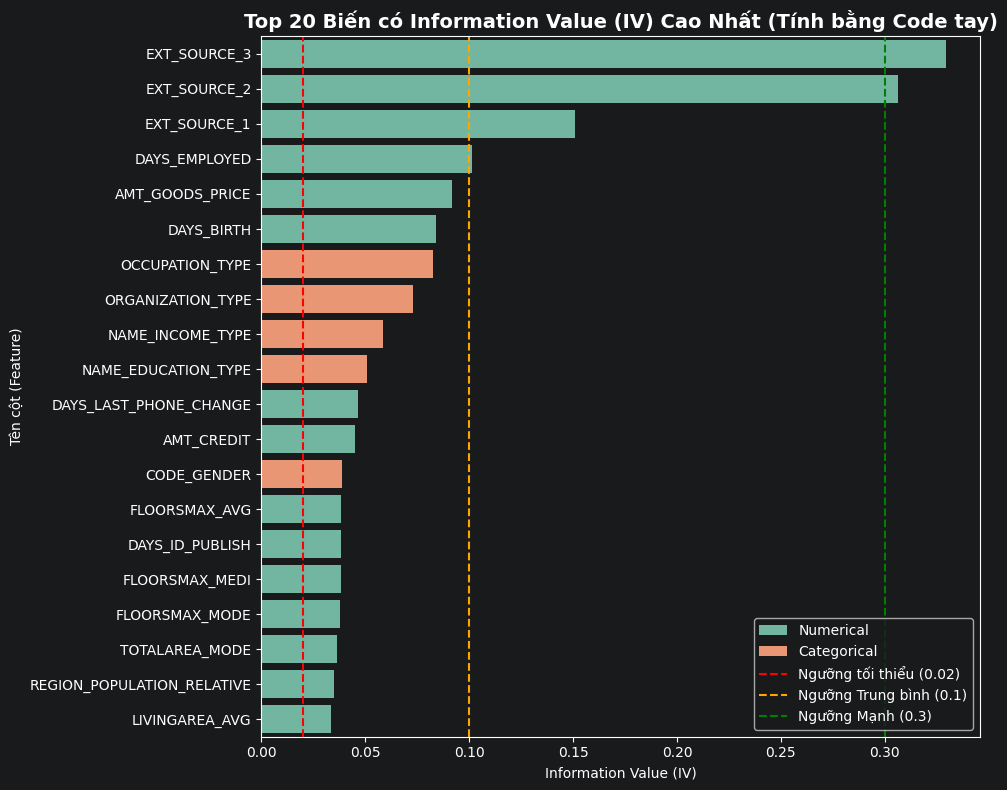

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# [1] HÀM TÍNH IV NGUYÊN BẢN (PURE PANDAS)
# ==========================================
def calculate_iv_pure(df, feature, target_col='TARGET', num_bins=10):
    """
    Tính Information Value (IV) thủ công cho 1 cột bằng Pandas
    """
    # Bản sao dữ liệu chứa cột feature và target
    data = df[[feature, target_col]].copy()

    # 1. Chia thùng (Binning)
    if pd.api.types.is_numeric_dtype(data[feature]):
        # Nếu là cột số: Chia thành num_bins khoảng (dùng qcut để cân bằng mẫu)
        # duplicates='drop' giúp né lỗi nếu cột có quá nhiều giá trị trùng lặp (ví dụ toàn số 0)
        try:
            data['bin'] = pd.qcut(data[feature], q=num_bins, duplicates='drop')
        except Exception:
            data['bin'] = pd.cut(data[feature], bins=num_bins, duplicates='drop')
    else:
        # Nếu là cột chữ/phân loại: Giữ nguyên từng category làm 1 bin
        data['bin'] = data[feature]

    # Xử lý missing values như một thùng riêng biệt
    data['bin'] = data['bin'].astype(str).fillna("Missing")

    # 2. Gom nhóm đếm số lượng Good (Target=0) và Bad (Target=1)
    stats = data.groupby('bin', observed=False)[target_col].agg(
        total_count='count',
        bad_count='sum'
    ).reset_index()

    stats['good_count'] = stats['total_count'] - stats['bad_count']

    # Tổng số Good và Bad trên toàn bộ dataset
    total_goods = stats['good_count'].sum()
    total_bads = stats['bad_count'].sum()

    # Nếu không có Good hoặc Bad trong dataset (trường hợp cực đoan) -> Bỏ qua
    if total_goods == 0 or total_bads == 0:
        return 0.0

    # 3. Tính % Good và % Bad cho từng thùng
    # Thêm 0.5 (Laplace smoothing) để tránh lỗi chia cho 0 hoặc log(0)
    stats['pct_good'] = (stats['good_count'] + 0.5) / total_goods
    stats['pct_bad'] = (stats['bad_count'] + 0.5) / total_bads

    # 4. Tính WOE và IV cho từng thùng
    stats['woe'] = np.log(stats['pct_good'] / stats['pct_bad'])
    stats['iv_bin'] = (stats['pct_good'] - stats['pct_bad']) * stats['woe']

    # 5. IV tổng là tổng IV của tất cả các thùng
    return stats['iv_bin'].sum()


# ==========================================
# [2] QUÉT TOÀN BỘ CỘT TRONG DATAFRAME
# ==========================================
print("Đang tính toán Information Value (IV) ")

# Lấy danh sách cột dự báo (Bỏ ID và TARGET)
features = [col for col in df_train.columns if col not in ["SK_ID_CURR", "TARGET"]]

iv_results = []
for col in features:
    iv_val = calculate_iv_pure(df_train, feature=col, target_col='TARGET', num_bins=10)
    col_type = "Categorical" if not pd.api.types.is_numeric_dtype(df_train[col]) else "Numerical"
    iv_results.append({"name": col, "type": col_type, "iv": iv_val})

# Chuyển thành DataFrame
df_iv_summary = pd.DataFrame(iv_results)

# Phân loại sức mạnh dự báo
def classify_iv(iv):
    if iv < 0.02:
        return "Rất yếu (Unpredictive)"
    elif iv < 0.1:
        return "Yếu (Weak)"
    elif iv < 0.3:
        return "Trung bình (Medium)"
    elif iv < 0.5:
        return "Mạnh (Strong)"
    else:
        return "Cực kỳ mạnh (Very Strong)"

df_iv_summary["Predictive Power"] = df_iv_summary["iv"].apply(classify_iv)
top20_iv = df_iv_summary.sort_values(by="iv", ascending=False).head(20)

# ==========================================
# [3] IN BẢNG VÀ VẼ BIỂU ĐỒ KẾT QUẢ
# ==========================================
print("\n" + "=" * 70)
print("BẢNG XẾP HẠNG TOP 20 CỘT CÓ INFORMATION VALUE (IV) CAO NHẤT")
print("=" * 70)
print(top20_iv[["name", "type", "iv", "Predictive Power"]].to_string(index=False))

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(
    x="iv",
    y="name",
    data=top20_iv,
    hue="type",
    palette="Set2"
)
plt.axvline(x=0.02, color="red", linestyle="--", label="Ngưỡng tối thiểu (0.02)")
plt.axvline(x=0.1, color="orange", linestyle="--", label="Ngưỡng Trung bình (0.1)")
plt.axvline(x=0.3, color="green", linestyle="--", label="Ngưỡng Mạnh (0.3)")

plt.title("Top 20 Biến có Information Value (IV) Cao Nhất (Tính bằng Code tay)", fontsize=14, fontweight="bold")
plt.xlabel("Information Value (IV)")
plt.ylabel("Tên cột (Feature)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


BẢNG THỐNG KÊ MÔ TẢ NHÓM 1 THEO TARGET (0: Trả nợ tốt | 1: Vỡ nợ)

--- Biến: EXT_SOURCE_1 ---
 TARGET     Mean   Median      Std  Missing_Pct
      0 0.511461 0.517452 0.208804    56.107129
      1 0.386968 0.361675 0.204729    59.500504

--- Biến: EXT_SOURCE_2 ---
 TARGET     Mean   Median      Std  Missing_Pct
      0 0.523479 0.573905 0.186277     0.215080
      1 0.410935 0.440381 0.213107     0.209466

--- Biến: EXT_SOURCE_3 ---
 TARGET     Mean   Median      Std  Missing_Pct
      0 0.520969 0.546023 0.190465    19.558096
      1 0.390717 0.379100 0.205810    22.868077


/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/1348163532.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['TARGET'] == 0][col].dropna(), label='TARGET = 0 (Tốt)', color='blue', shade=True, alpha=0.3)
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/1348163532.py:33: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['TARGET'] == 1][col].dropna(), label='TARGET = 1 (Vỡ nợ)', color='red', shade=True, alpha=0.3)
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/1348163532.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_trai

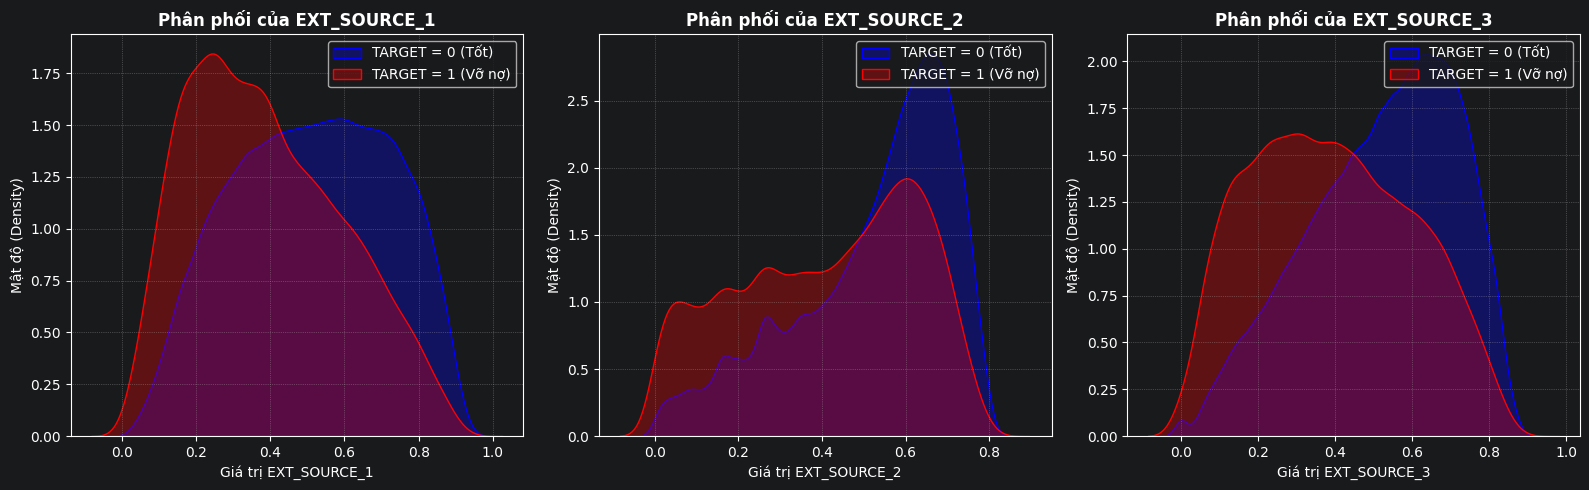

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [1] Danh sách 3 biến Key nhóm 1
ext_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# [2] Bảng Thống kê Mô tả (Mean, Median, Std, Missing %) theo TARGET (0 vs 1)
print("="*85)
print("BẢNG THỐNG KÊ MÔ TẢ NHÓM 1 THEO TARGET (0: Trả nợ tốt | 1: Vỡ nợ)")
print("="*85)

for col in ext_features:
    summary = df_train.groupby('TARGET')[col].agg(
        Mean='mean',
        Median='median',
        Std='std',
        Missing_Pct=lambda x: (x.isnull().sum() / len(x)) * 100
    ).reset_index()

    print(f"\n--- Biến: {col} ---")
    print(summary.to_string(index=False))

# [3] Trực quan hóa bằng Biểu đồ Mật độ KDE Plot
plt.figure(figsize=(16, 5))

for i, col in enumerate(ext_features, 1):
    plt.subplot(1, 3, i)

    # Vẽ phân phối cho Target = 0 (Xanh) và Target = 1 (Đỏ)
    sns.kdeplot(df_train[df_train['TARGET'] == 0][col].dropna(), label='TARGET = 0 (Tốt)', color='blue', shade=True, alpha=0.3)
    sns.kdeplot(df_train[df_train['TARGET'] == 1][col].dropna(), label='TARGET = 1 (Vỡ nợ)', color='red', shade=True, alpha=0.3)

    plt.title(f'Phân phối của {col}', fontsize=12, fontweight='bold')
    plt.xlabel(f'Giá trị {col}')
    plt.ylabel('Mật độ (Density)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

BẢNG THỐNG KÊ MÔ TẢ BIẾN SỐ NHÓM 2 THEO TARGET (0 vs 1)

--- Biến Số: AMT_GOODS_PRICE ---
 TARGET          Mean   Median           Std  Missing_Pct
      0 542736.795003 450000.0 373785.493534     0.090914
      1 488972.412554 450000.0 311636.495297     0.084592

--- Biến Số: AMT_CREDIT ---
 TARGET          Mean   Median           Std  Missing_Pct
      0 602648.282002 517788.0 406845.907710          0.0
      1 557778.527674 497520.0 346433.235646          0.0

BẢNG THỐNG KÊ BIẾN CHỮ: NAME_INCOME_TYPE
    NAME_INCOME_TYPE  Total_Count  Default_Count  Default_Rate  Default_Rate_%  Missing_Pct
             Working       158774          15224      0.095885        9.588472          0.0
Commercial associate        71617           5360      0.074843        7.484257          0.0
           Pensioner        55362           2982      0.053864        5.386366          0.0
       State servant        21703           1249      0.057550        5.754965          0.0
          Unemployed           

/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/1459703455.py:37: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['TARGET'] == 0]['AMT_GOODS_PRICE'].dropna(), label='TARGET = 0 (Tốt)', color='blue', shade=True, alpha=0.3)
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/1459703455.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['TARGET'] == 1]['AMT_GOODS_PRICE'].dropna(), label='TARGET = 1 (Vỡ nợ)', color='red', shade=True, alpha=0.3)
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/1459703455.py:47: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  

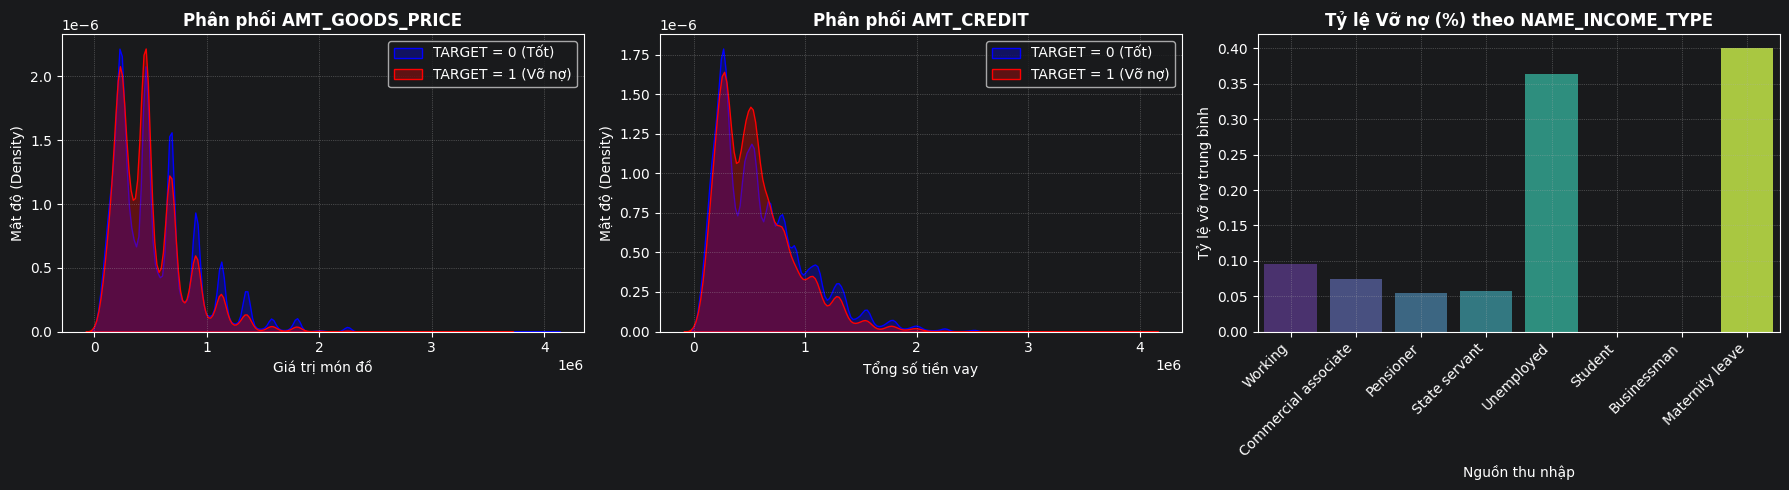

In [20]:


# [1] Thống kê mô tả cho 2 biến Số (AMT_GOODS_PRICE, AMT_CREDIT)
num_features_g2 = ['AMT_GOODS_PRICE', 'AMT_CREDIT']

print("="*85)
print("BẢNG THỐNG KÊ MÔ TẢ BIẾN SỐ NHÓM 2 THEO TARGET (0 vs 1)")
print("="*85)

for col in num_features_g2:
    summary = df_train.groupby('TARGET')[col].agg(
        Mean='mean',
        Median='median',
        Std='std',
        Missing_Pct=lambda x: (x.isnull().sum() / len(x)) * 100
    ).reset_index()
    print(f"\n--- Biến Số: {col} ---")
    print(summary.to_string(index=False))

# [2] Thống kê tỷ lệ vỡ nợ (Default Rate) cho Biến Chữ (NAME_INCOME_TYPE)
print("\n" + "="*85)
print("BẢNG THỐNG KÊ BIẾN CHỮ: NAME_INCOME_TYPE")
print("="*85)
income_summary = df_train.groupby('NAME_INCOME_TYPE').agg(
    Total_Count=('TARGET', 'count'),
    Default_Count=('TARGET', 'sum'),
    Default_Rate=('TARGET', 'mean')
).reset_index()
income_summary['Default_Rate_%'] = income_summary['Default_Rate'] * 100
income_summary['Missing_Pct'] = (df_train['NAME_INCOME_TYPE'].isnull().sum() / len(df_train)) * 100
print(income_summary.sort_values(by='Total_Count', ascending=False).to_string(index=False))


# [3] Trực quan hóa Biểu đồ
plt.figure(figsize=(18, 5))

# Đồ thị 1: KDE Plot cho AMT_GOODS_PRICE
plt.subplot(1, 3, 1)
sns.kdeplot(df_train[df_train['TARGET'] == 0]['AMT_GOODS_PRICE'].dropna(), label='TARGET = 0 (Tốt)', color='blue', shade=True, alpha=0.3)
sns.kdeplot(df_train[df_train['TARGET'] == 1]['AMT_GOODS_PRICE'].dropna(), label='TARGET = 1 (Vỡ nợ)', color='red', shade=True, alpha=0.3)
plt.title('Phân phối AMT_GOODS_PRICE', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị món đồ')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Đồ thị 2: KDE Plot cho AMT_CREDIT
plt.subplot(1, 3, 2)
sns.kdeplot(df_train[df_train['TARGET'] == 0]['AMT_CREDIT'].dropna(), label='TARGET = 0 (Tốt)', color='blue', shade=True, alpha=0.3)
sns.kdeplot(df_train[df_train['TARGET'] == 1]['AMT_CREDIT'].dropna(), label='TARGET = 1 (Vỡ nợ)', color='red', shade=True, alpha=0.3)
plt.title('Phân phối AMT_CREDIT', fontsize=12, fontweight='bold')
plt.xlabel('Tổng số tiền vay')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Đồ thị 3: Barplot Tỷ lệ vỡ nợ theo NAME_INCOME_TYPE
plt.subplot(1, 3, 3)
income_order = df_train['NAME_INCOME_TYPE'].value_counts().index
sns.barplot(data=df_train, x='NAME_INCOME_TYPE', y='TARGET', order=income_order, ci=None, palette='viridis')
plt.title('Tỷ lệ Vỡ nợ (%) theo NAME_INCOME_TYPE', fontsize=12, fontweight='bold')
plt.xlabel('Nguồn thu nhập')
plt.ylabel('Tỷ lệ vỡ nợ trung bình')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/2899638002.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/2899638002.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


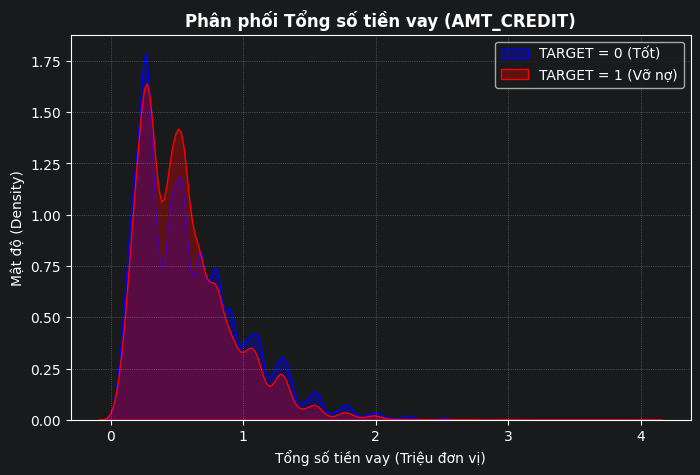

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Chia trực tiếp cho 1,000,000 để trục X hiện đơn vị Triệu
sns.kdeplot(
    df_train[df_train['TARGET'] == 0]['AMT_CREDIT'].dropna() / 1e6,
    label='TARGET = 0 (Tốt)',
    color='blue',
    shade=True,
    alpha=0.3,
)
sns.kdeplot(
    df_train[df_train['TARGET'] == 1]['AMT_CREDIT'].dropna() / 1e6,
    label='TARGET = 1 (Vỡ nợ)',
    color='red',
    shade=True,
    alpha=0.3,
)

plt.title('Phân phối Tổng số tiền vay (AMT_CREDIT)', fontsize=12, fontweight='bold')
plt.xlabel('Tổng số tiền vay (Triệu đơn vị)', fontsize=10)  # Đổi nhãn rõ ràng
plt.ylabel('Mật độ (Density)', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3409225903.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3409225903.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3409225903.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3409225903.py:39: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



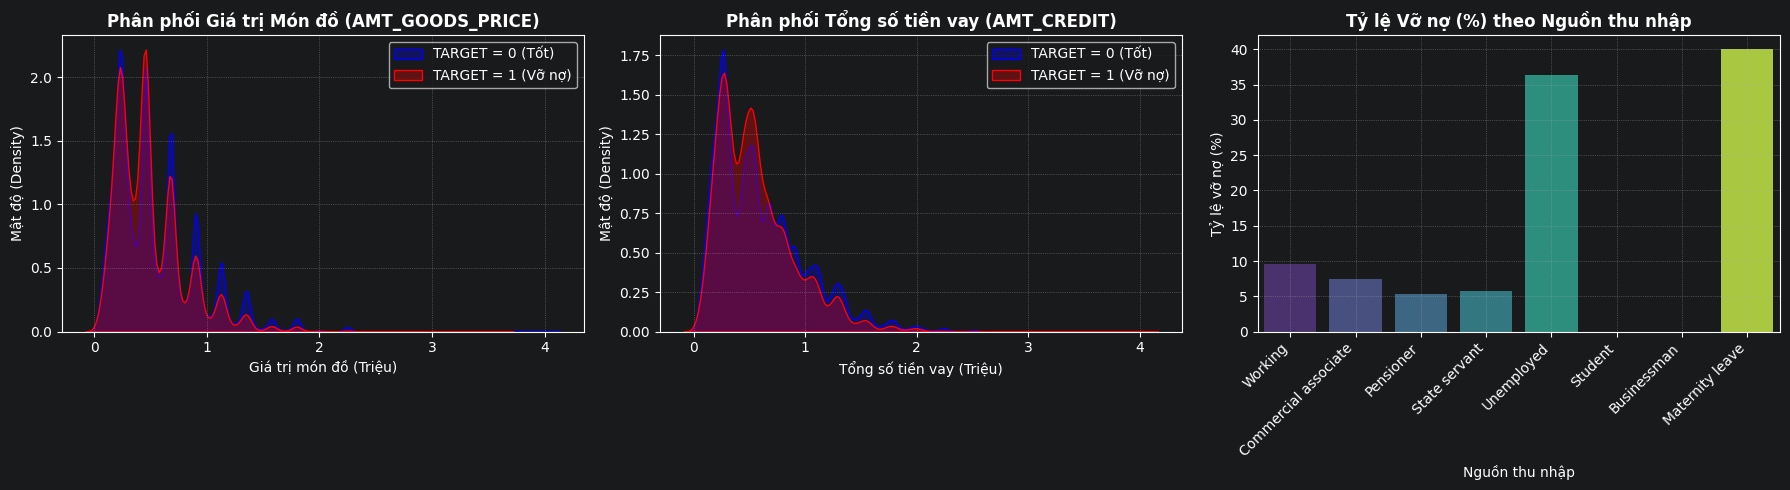

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# 1. Đồ thị 1: AMT_GOODS_PRICE (Chia cho 1e6 để ra đơn vị Triệu)
plt.subplot(1, 3, 1)
sns.kdeplot(
    df_train[df_train['TARGET'] == 0]['AMT_GOODS_PRICE'].dropna() / 1e6,
    label='TARGET = 0 (Tốt)',
    color='blue',
    shade=True,
    alpha=0.3,
)
sns.kdeplot(
    df_train[df_train['TARGET'] == 1]['AMT_GOODS_PRICE'].dropna() / 1e6,
    label='TARGET = 1 (Vỡ nợ)',
    color='red',
    shade=True,
    alpha=0.3,
)
plt.title(
    'Phân phối Giá trị Món đồ (AMT_GOODS_PRICE)', fontsize=12, fontweight='bold'
)
plt.xlabel('Giá trị món đồ (Triệu)', fontsize=10)
plt.ylabel('Mật độ (Density)', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Đồ thị 2: AMT_CREDIT (Chia cho 1e6 để ra đơn vị Triệu)
plt.subplot(1, 3, 2)
sns.kdeplot(
    df_train[df_train['TARGET'] == 0]['AMT_CREDIT'].dropna() / 1e6,
    label='TARGET = 0 (Tốt)',
    color='blue',
    shade=True,
    alpha=0.3,
)
sns.kdeplot(
    df_train[df_train['TARGET'] == 1]['AMT_CREDIT'].dropna() / 1e6,
    label='TARGET = 1 (Vỡ nợ)',
    color='red',
    shade=True,
    alpha=0.3,
)
plt.title('Phân phối Tổng số tiền vay (AMT_CREDIT)', fontsize=12, fontweight='bold')
plt.xlabel('Tổng số tiền vay (Triệu)', fontsize=10)
plt.ylabel('Mật độ (Density)', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 3. Đồ thị 3: Barplot Tỷ lệ Vỡ nợ theo NAME_INCOME_TYPE (% rõ ràng)
plt.subplot(1, 3, 3)
income_order = df_train['NAME_INCOME_TYPE'].value_counts().index
# Nhân TARGET với 100 để trục Y thể hiện trực tiếp số % (VD: 10%, 20%...)
sns.barplot(
    data=df_train.assign(TARGET_PCT=df_train['TARGET'] * 100),
    x='NAME_INCOME_TYPE',
    y='TARGET_PCT',
    order=income_order,
    ci=None,
    palette='viridis',
)
plt.title(
    'Tỷ lệ Vỡ nợ (%) theo Nguồn thu nhập', fontsize=12, fontweight='bold'
)
plt.xlabel('Nguồn thu nhập', fontsize=10)
plt.ylabel('Tỷ lệ vỡ nợ (%)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


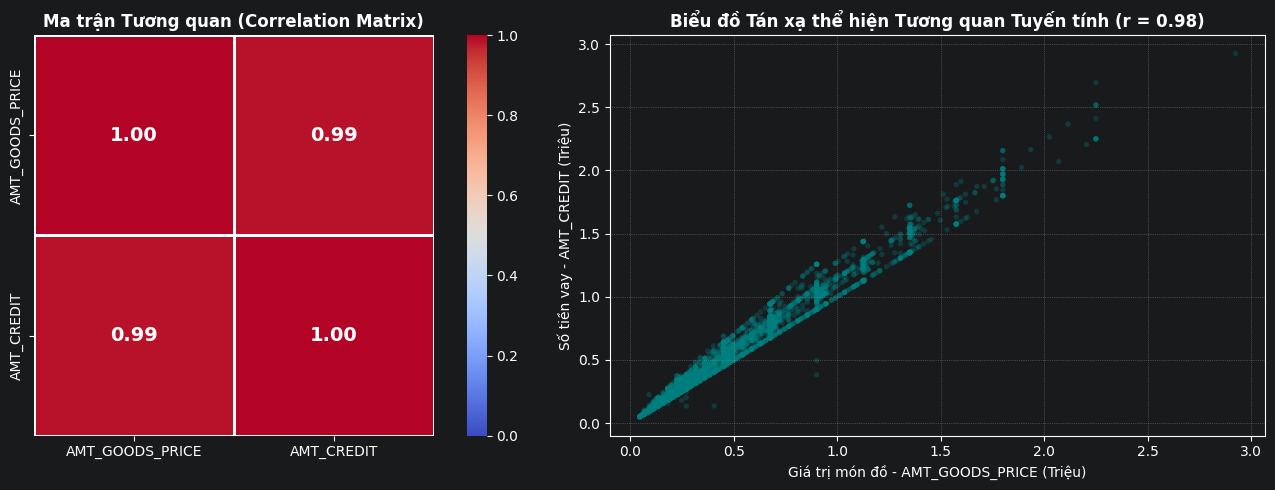

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(14, 5))

# [1] Biểu đồ 1: Ma trận Tương quan (Correlation Heatmap)
plt.subplot(1, 2, 1)
# Tính ma trận tương quan cho 2 biến
corr_matrix = df_train[['AMT_GOODS_PRICE', 'AMT_CREDIT']].corr()

# Vẽ Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    cbar=True,
    linewidths=1,
    square=True,
    annot_kws={'size': 14, 'weight': 'bold'},
)
plt.title(
    'Ma trận Tương quan (Correlation Matrix)', fontsize=12, fontweight='bold'
)


# [2] Biểu đồ 2: Biểu đồ Tán xạ (Scatter Plot chia nhỏ mẫu để chạy nhanh)
plt.subplot(1, 2, 2)
# Lấy ngẫu nhiên 5,000 dòng để vẽ nhanh, tránh bị giật lag
sample_df = df_train[['AMT_GOODS_PRICE', 'AMT_CREDIT']].dropna().sample(n=5000, random_state=42)

plt.scatter(
    sample_df['AMT_GOODS_PRICE'] / 1e6,
    sample_df['AMT_CREDIT'] / 1e6,
    alpha=0.3,
    color='teal',
    edgecolor='none',
    s=15,
)
plt.title(
    'Biểu đồ Tán xạ thể hiện Tương quan Tuyến tính (r = 0.98)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Giá trị món đồ - AMT_GOODS_PRICE (Triệu)', fontsize=10)
plt.ylabel('Số tiền vay - AMT_CREDIT (Triệu)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

BẢNG THỐNG KÊ MÔ TẢ BIẾN SỐ NHÓM 3 THEO TARGET

--- Biến Số: Employment_Years ---
 TARGET     Mean   Median      Std  Missing_Pct
      0 6.675264 4.629706 6.495303    18.530808
      1 4.968977 3.367556 5.064314    12.044310

--- Biến Số: Age ---
 TARGET      Mean    Median       Std  Missing_Pct
      0 44.183919 43.468857 11.948531          0.0
      1 40.752438 39.101985 11.479383          0.0

--- Biến Số: Phone_Change_Years ---
 TARGET     Mean   Median      Std  Missing_Pct
      0 2.673205 2.124572 2.275731     0.000354
      1 2.214365 1.626283 2.075539     0.000000

--- Biến Số: TOTALAREA_MODE ---
 TARGET     Mean  Median      Std  Missing_Pct
      0 0.103507  0.0691 0.108043    47.658887
      1 0.089769  0.0617 0.098530    55.210473

BẢNG THỐNG KÊ BIẾN CHỮ NHÓM 3 (TỶ LỆ VỠ NỢ %)

--- Biến Chữ: OCCUPATION_TYPE ---
      OCCUPATION_TYPE  Tong_So_Ho_So  So_Ho_So_Vo_No  Ty_Le_Vo_No  Ty_Le_Vo_No_%  Missing_Pct
             Laborers          55186            5838     0.105788   

/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:73: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:80: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:73: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:80: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


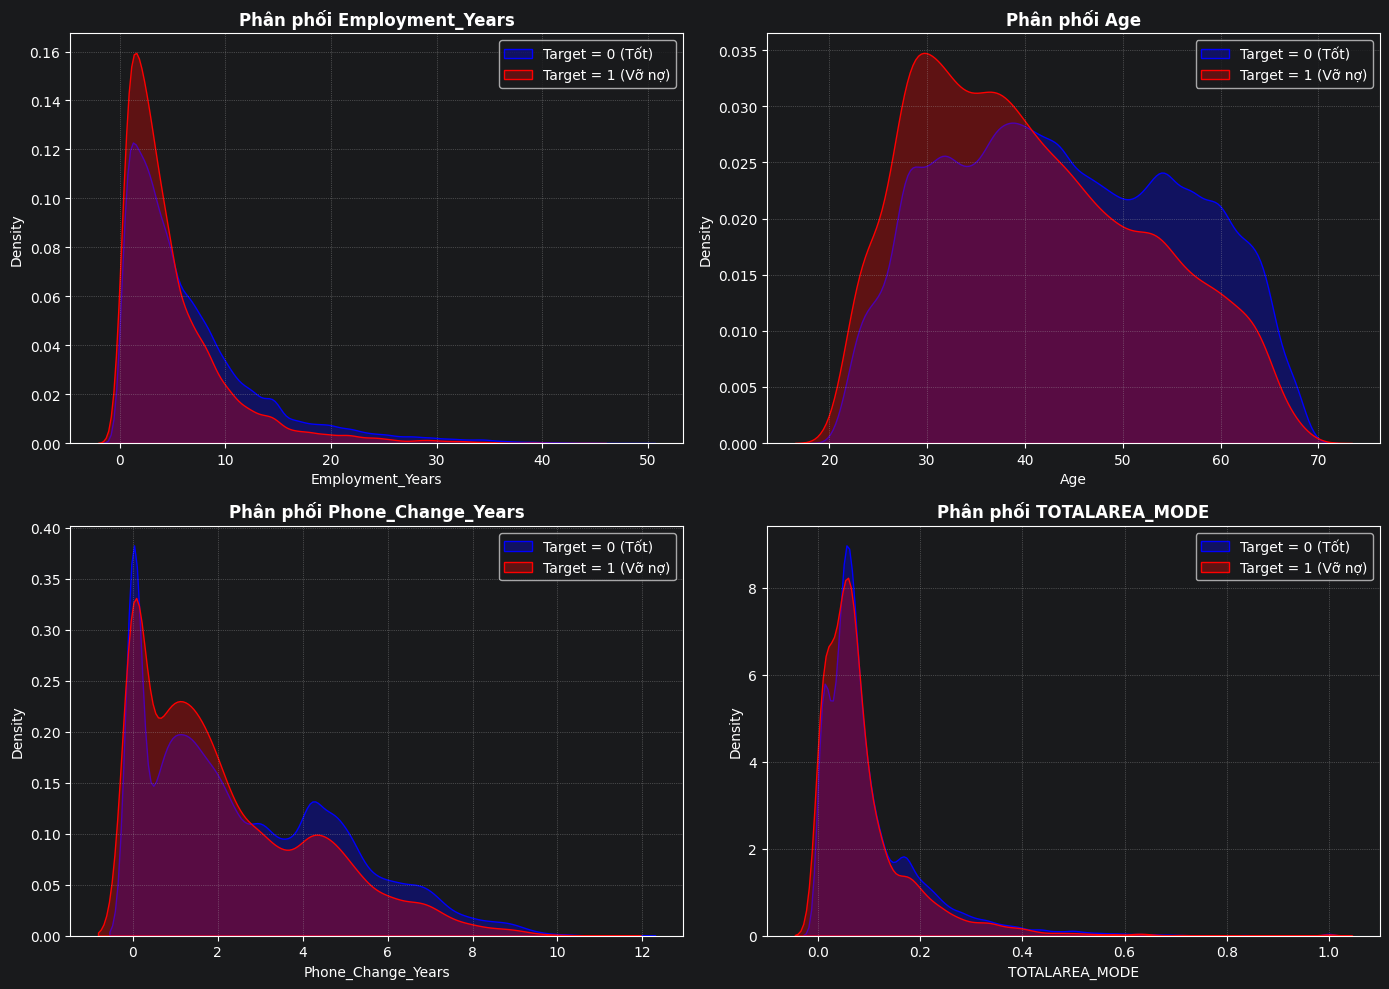

/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data=df_train[df_train[col].isin(top_order)].assign(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:99: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/n7/l05n2y3d6vz6m0kjtql6slhm0000gn/T/ipykernel_20587/3872905743.py:100: PerformanceWarning: DataFram

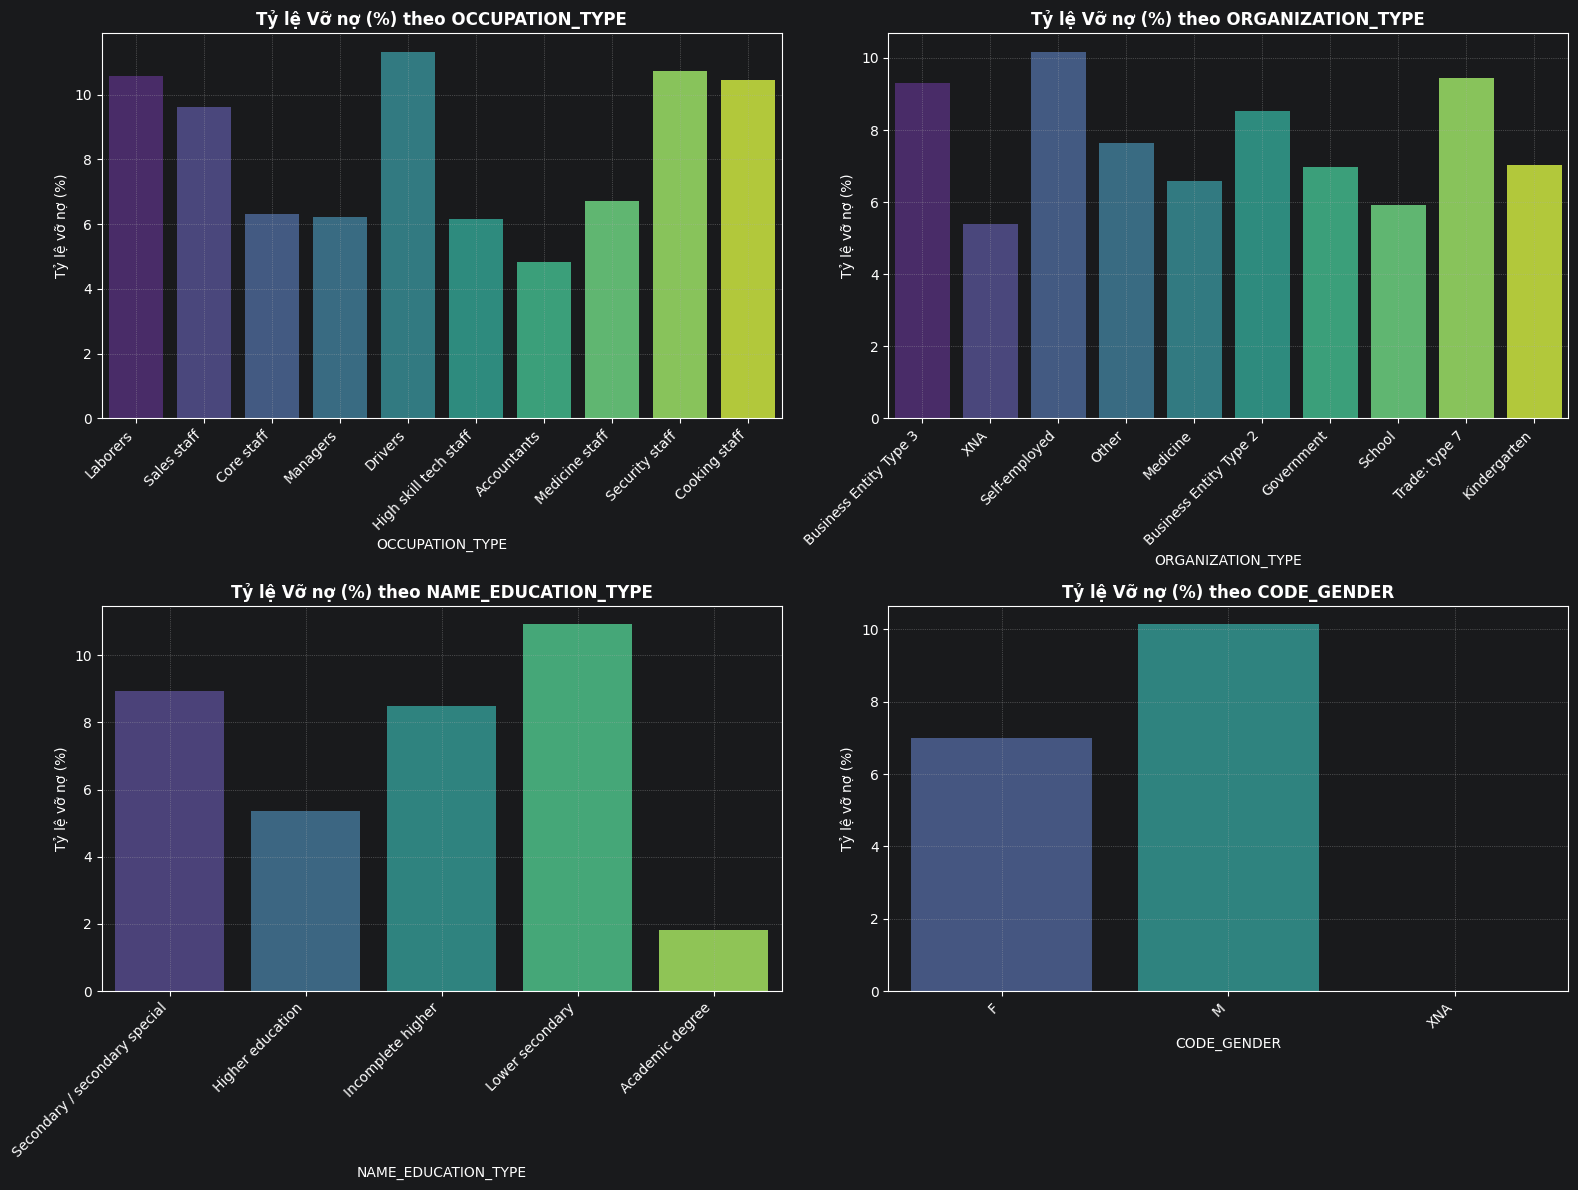

In [27]:


df_g3 = df_train.copy()

# Chuyển đổi các biến ngày âm sang số năm/tuổi cho dễ nhìn
df_g3['Age'] = -df_g3['DAYS_BIRTH'] / 365.25
df_g3['Employment_Years'] = np.where(
    df_g3['DAYS_EMPLOYED'] == 365243,
    np.nan,
    -df_g3['DAYS_EMPLOYED'] / 365.25,
)
df_g3['Phone_Change_Years'] = -df_g3['DAYS_LAST_PHONE_CHANGE'] / 365.25

# 1. THỐNG KÊ BIẾN SỐ
num_cols_g3 = [
    'Employment_Years',
    'Age',
    'Phone_Change_Years',
    'TOTALAREA_MODE',
]

print("=" * 85)
print("BẢNG THỐNG KÊ MÔ TẢ BIẾN SỐ NHÓM 3 THEO TARGET")
print("=" * 85)
for col in num_cols_g3:
  summary = (
      df_g3.groupby('TARGET')[col]
      .agg(
          Mean='mean',
          Median='median',
          Std='std',
          Missing_Pct=lambda x: (x.isnull().sum() / len(x)) * 100,
      )
      .reset_index()
  )
  print(f'\n--- Biến Số: {col} ---')
  print(summary.to_string(index=False))

# 2. THỐNG KÊ BIẾN CHỮ
cat_cols_g3 = [
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',
    'NAME_EDUCATION_TYPE',
    'CODE_GENDER',
]

print('\n' + '=' * 85)
print('BẢNG THỐNG KÊ BIẾN CHỮ NHÓM 3 (TỶ LỆ VỠ NỢ %)')
print('=' * 85)
for col in cat_cols_g3:
  cat_summary = (
      df_train.groupby(col)
      .agg(
          Tong_So_Ho_So=('TARGET', 'count'),
          So_Ho_So_Vo_No=('TARGET', 'sum'),
          Ty_Le_Vo_No=('TARGET', 'mean'),
      )
      .reset_index()
  )
  cat_summary['Ty_Le_Vo_No_%'] = cat_summary['Ty_Le_Vo_No'] * 100
  cat_summary['Missing_Pct'] = (
      df_train[col].isnull().sum() / len(df_train)
  ) * 100
  print(f'\n--- Biến Chữ: {col} ---')
  print(
      cat_summary.sort_values(by='Tong_So_Ho_So', ascending=False).to_string(
          index=False
      )
  )

# 3. VẼ ĐỒ THỊ BIẾN SỐ (KDE PLOTS)
plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols_g3, 1):
  plt.subplot(2, 2, i)
  sns.kdeplot(
      df_g3[df_g3['TARGET'] == 0][col].dropna(),
      label='Target = 0 (Tốt)',
      color='blue',
      shade=True,
      alpha=0.3,
  )
  sns.kdeplot(
      df_g3[df_g3['TARGET'] == 1][col].dropna(),
      label='Target = 1 (Vỡ nợ)',
      color='red',
      shade=True,
      alpha=0.3,
  )
  plt.title(f'Phân phối {col}', fontweight='bold')
  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend()
plt.tight_layout()
plt.show()

# 4. VẼ ĐỒ THỊ BIẾN CHỮ (BARPLOTS)
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols_g3, 1):
  plt.subplot(2, 2, i)
  # Lấy top 10 danh mục phổ biến nhất nếu cột đó có quá nhiều nhóm (như ORGANIZATION_TYPE)
  top_order = df_train[col].value_counts().head(10).index
  sns.barplot(
      data=df_train[df_train[col].isin(top_order)].assign(
          TARGET_PCT=df_train['TARGET'] * 100
      ),
      x=col,
      y='TARGET_PCT',
      order=top_order,
      ci=None,
      palette='viridis',
  )
  plt.title(f'Tỷ lệ Vỡ nợ (%) theo {col}', fontweight='bold')
  plt.ylabel('Tỷ lệ vỡ nợ (%)')
  plt.xticks(rotation=45, ha='right')
  plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd

# Danh sách các biến chữ trong Nhóm 3
cat_cols_g3 = [
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',
    'NAME_EDUCATION_TYPE',
    'CODE_GENDER',
]

print("=" * 85)
print("BẢNG THỐNG KÊ BIẾN CHỮ NHÓM 3 (CATEGORICAL SUMMARY)")
print("=" * 85)

for col in cat_cols_g3:
  summary = (
      df_train.groupby(col)
      .agg(
          Total_Count=('TARGET', 'count'),
          Default_Count=('TARGET', 'sum'),
          Default_Rate=('TARGET', 'mean'),
      )
      .reset_index()
  )
  summary['Default_Rate_%'] = summary['Default_Rate'] * 100
  summary['Missing_Pct'] = (
      df_train[col].isnull().sum() / len(df_train)
  ) * 100

  # Đổi tên cột hiển thị danh mục thành NAME_<FEATURE> cho đẹp
  summary = summary.rename(columns={col: f'{col}_CATEGORY'})

  print(f'\n--- Biến Chữ: {col} ---')
  print(
      summary.sort_values(by='Total_Count', ascending=False).to_string(
          index=False
      )
  )


BẢNG THỐNG KÊ BIẾN CHỮ NHÓM 3 (CATEGORICAL SUMMARY)

--- Biến Chữ: OCCUPATION_TYPE ---
OCCUPATION_TYPE_CATEGORY  Total_Count  Default_Count  Default_Rate  Default_Rate_%  Missing_Pct
                Laborers        55186           5838      0.105788       10.578770    31.345545
             Sales staff        32102           3092      0.096318        9.631799    31.345545
              Core staff        27570           1738      0.063040        6.303954    31.345545
                Managers        21371           1328      0.062140        6.214028    31.345545
                 Drivers        18603           2107      0.113261       11.326130    31.345545
   High skill tech staff        11380            701      0.061599        6.159930    31.345545
             Accountants         9813            474      0.048303        4.830327    31.345545
          Medicine staff         8537            572      0.067002        6.700246    31.345545
          Security staff         6721            

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Tạo dataframe làm việc riêng
df_multi = df_train.copy()

# Chuyển đổi các biến thời gian sang năm (dương)
df_multi['Age'] = -df_multi['DAYS_BIRTH'] / 365.25
df_multi['Employment_Years'] = np.where(
    df_multi['DAYS_EMPLOYED'] == 365243,
    np.nan,
    -df_multi['DAYS_EMPLOYED'] / 365.25,
)
df_multi['Credit_M'] = df_multi['AMT_CREDIT'] / 1e6

# Danh sách 10 biến theo yêu cầu của bạn:
# 1. EXT_SOURCE_3
# 2. EXT_SOURCE_2
# 3. AMT_CREDIT (Credit_M)
# 4. NAME_INCOME_TYPE
# 5. Age
# 6. Employment_Years
# 7. ORGANIZATION_TYPE
# 8. OCCUPATION_TYPE
# 9. NAME_EDUCATION_TYPE
# 10. CODE_GENDER

print("✅ Đã khởi động lại dữ liệu thành công với đúng danh sách 10 biến của bạn!")

✅ Đã khởi động lại dữ liệu thành công với đúng danh sách 10 biến của bạn!


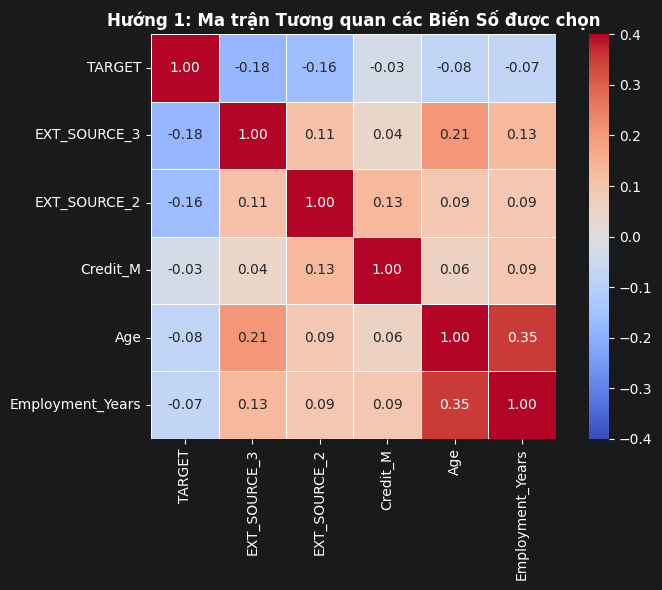

In [34]:
# [HƯỚNG 1] Ma trận tương quan các biến số trong danh sách yêu cầu
num_selected = [
    'TARGET',
    'EXT_SOURCE_3',
    'EXT_SOURCE_2',
    'Credit_M',
    'Age',
    'Employment_Years',
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_multi[num_selected].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-0.4,
    vmax=0.4,
    cbar=True,
    square=True,
    linewidths=0.5,
)
plt.title(
    'Hướng 1: Ma trận Tương quan các Biến Số được chọn',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

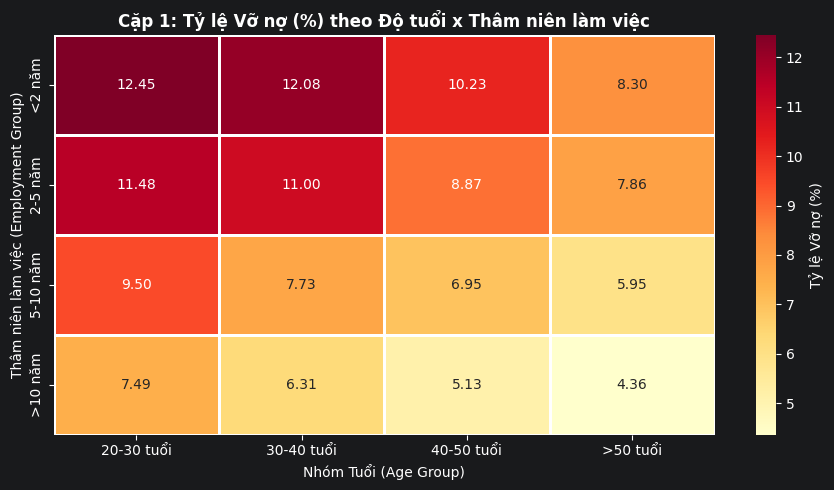

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# [1] Chuẩn bị dữ liệu quy đổi
df_pair1 = df_train.copy()
df_pair1['Age'] = -df_pair1['DAYS_BIRTH'] / 365.25
df_pair1['Employment_Years'] = np.where(
    df_pair1['DAYS_EMPLOYED'] == 365243,
    np.nan,
    -df_pair1['DAYS_EMPLOYED'] / 365.25,
)

# [2] Gom nhóm (Binning) để tạo Binned Heatmap
df_pair1['Age_Group'] = pd.cut(
    df_pair1['Age'],
    bins=[20, 30, 40, 50, 70],
    labels=['20-30 tuổi', '30-40 tuổi', '40-50 tuổi', '>50 tuổi'],
)

df_pair1['Emp_Group'] = pd.cut(
    df_pair1['Employment_Years'],
    bins=[-1, 2, 5, 10, 50],
    labels=['<2 năm', '2-5 năm', '5-10 năm', '>10 năm'],
)

# [3] Tính Pivot Table tỷ lệ vỡ nợ %
pivot_pair1 = df_pair1.pivot_table(
    index='Emp_Group', columns='Age_Group', values='TARGET', aggfunc='mean'
)

# [4] Trực quan hóa Heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(
    pivot_pair1 * 100,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Tỷ lệ Vỡ nợ (%)'},
    linewidths=1,
)
plt.title(
    'Cặp 1: Tỷ lệ Vỡ nợ (%) theo Độ tuổi x Thâm niên làm việc',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Nhóm Tuổi (Age Group)', fontsize=10)
plt.ylabel('Thâm niên làm việc (Employment Group)', fontsize=10)
plt.tight_layout()
plt.show()

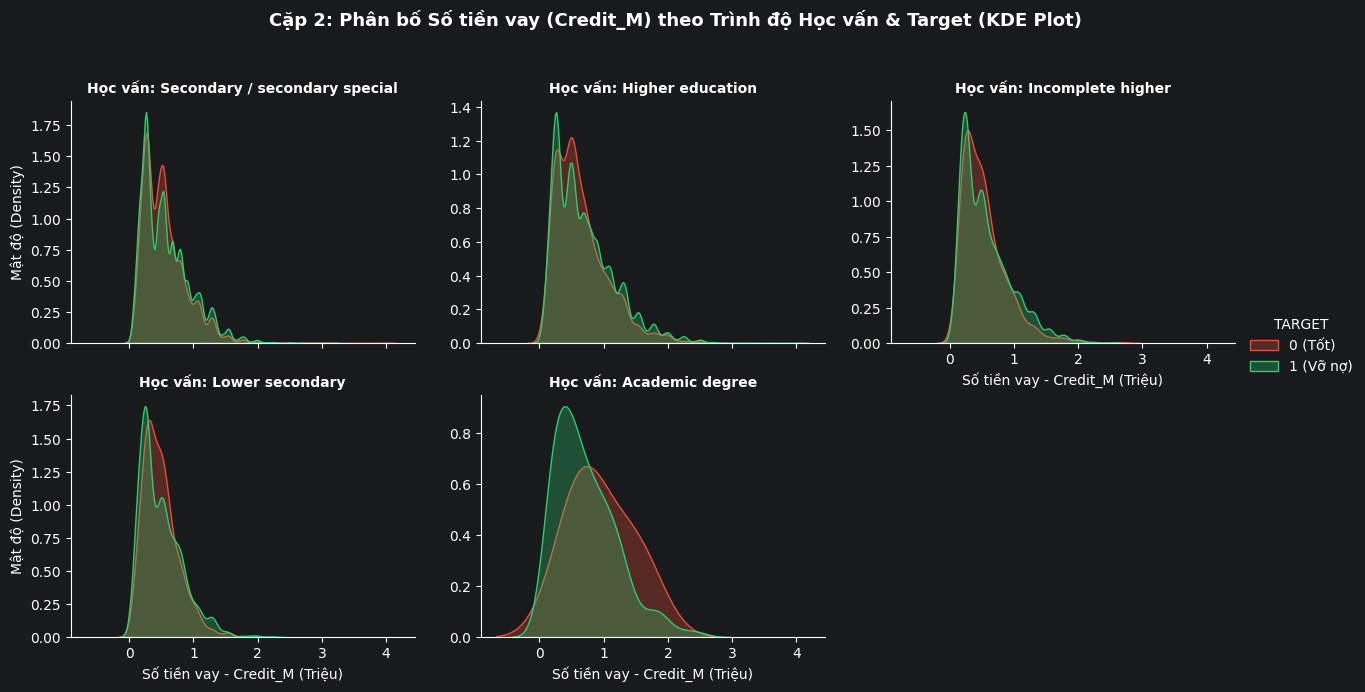

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# [1] Chuẩn bị dữ liệu đổi đơn vị tiền sang Triệu
df_pair2 = df_train.copy()
df_pair2['Credit_M'] = df_pair2['AMT_CREDIT'] / 1e6

# [2] Trực quan hóa bằng FacetGrid KDE Plot
g = sns.FacetGrid(
    df_pair2,
    col='NAME_EDUCATION_TYPE',
    col_wrap=3,
    height=3.5,
    aspect=1.2,
    sharey=False,
)

g.map_dataframe(
    sns.kdeplot,
    x='Credit_M',
    hue='TARGET',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    common_norm=False,
    fill=True,  # Đã cập nhật từ shade=True sang fill=True để hết FutureWarning
    alpha=0.3,
)

g.set_axis_labels('Số tiền vay - Credit_M (Triệu)', 'Mật độ (Density)')
g.set_titles(col_template='Học vấn: {col_name}', weight='bold')
g.add_legend(title='TARGET', labels=['0 (Tốt)', '1 (Vỡ nợ)'])

plt.subplots_adjust(top=0.85)
g.fig.suptitle(
    'Cặp 2: Phân bố Số tiền vay (Credit_M) theo Trình độ Học vấn & Target (KDE'
    ' Plot)',
    fontsize=13,
    fontweight='bold',
)
plt.show()

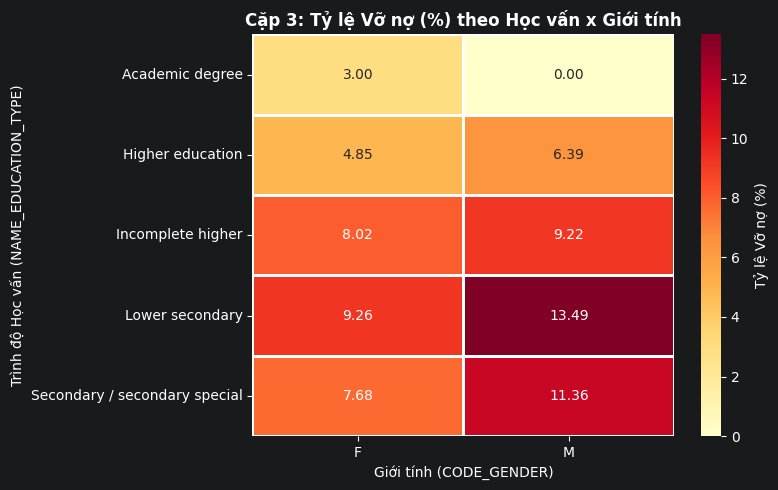

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# [1] Chuẩn bị dữ liệu và Pivot Table
df_pair3 = df_train.copy()

pivot_pair3 = df_pair3.pivot_table(
    index='NAME_EDUCATION_TYPE',
    columns='CODE_GENDER',
    values='TARGET',
    aggfunc='mean',
)

# Loại bỏ nhãn rác XNA nếu có
if 'XNA' in pivot_pair3.columns:
  pivot_pair3 = pivot_pair3.drop(columns=['XNA'])

# [2] Trực quan hóa Cross-Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_pair3 * 100,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Tỷ lệ Vỡ nợ (%)'},
    linewidths=1,
)
plt.title(
    'Cặp 3: Tỷ lệ Vỡ nợ (%) theo Học vấn x Giới tính',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Giới tính (CODE_GENDER)', fontsize=10)
plt.ylabel('Trình độ Học vấn (NAME_EDUCATION_TYPE)', fontsize=10)
plt.tight_layout()
plt.show()

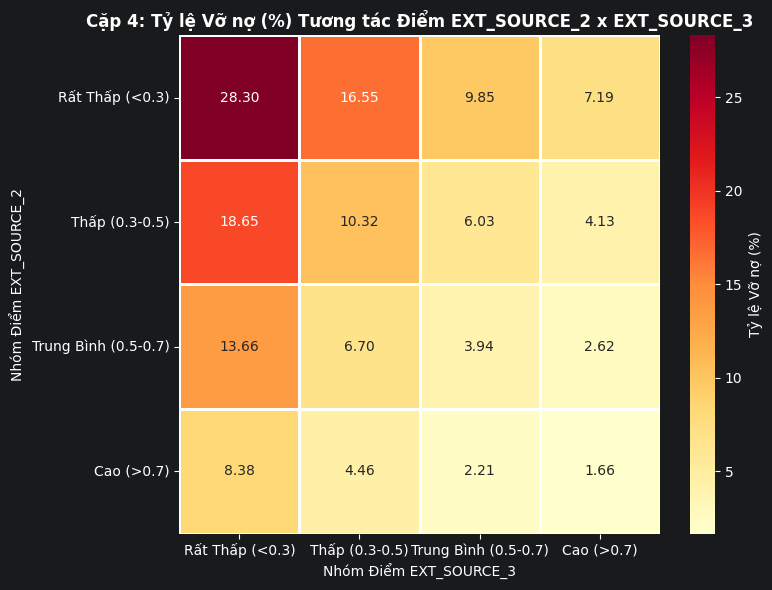

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# [1] Chuẩn bị dữ liệu và Gom nhóm Điểm Tín Dụng
df_pair4 = df_train.dropna(subset=['EXT_SOURCE_2', 'EXT_SOURCE_3']).copy()

df_pair4['EXT2_Group'] = pd.cut(
    df_pair4['EXT_SOURCE_2'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Rất Thấp (<0.3)', 'Thấp (0.3-0.5)', 'Trung Bình (0.5-0.7)', 'Cao (>0.7)'],
)

df_pair4['EXT3_Group'] = pd.cut(
    df_pair4['EXT_SOURCE_3'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Rất Thấp (<0.3)', 'Thấp (0.3-0.5)', 'Trung Bình (0.5-0.7)', 'Cao (>0.7)'],
)

# [2] Tính Pivot Table % Vỡ nợ
pivot_pair4 = df_pair4.pivot_table(
    index='EXT2_Group', columns='EXT3_Group', values='TARGET', aggfunc='mean'
)

# [3] Trực quan hóa Heatmap Tương tác Điểm
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_pair4 * 100,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Tỷ lệ Vỡ nợ (%)'},
    linewidths=1,
)
plt.title(
    'Cặp 4: Tỷ lệ Vỡ nợ (%) Tương tác Điểm EXT_SOURCE_2 x EXT_SOURCE_3',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Nhóm Điểm EXT_SOURCE_3', fontsize=10)
plt.ylabel('Nhóm Điểm EXT_SOURCE_2', fontsize=10)
plt.tight_layout()
plt.show()